In [1]:
# Cài đặt các thư viện xử lý âm thanh và model
!pip install -q transformers datasets torchaudio evaluate librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import torchaudio
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    AutoFeatureExtractor, 
    AutoModelForAudioClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback,
    logging
)
import evaluate
import warnings

# Ẩn các cảnh báo không cần thiết
warnings.filterwarnings('ignore')
logging.set_verbosity_error()

In [3]:
DATASET_PATH = "/kaggle/input/vi-26-dialect-classification/vi_26_dialect" 
split_info_path = os.path.join(DATASET_PATH, "split_info.csv")

df = pd.read_csv(split_info_path)

# Đệm thêm số 0 ở đầu (VD: 739 -> '000739') để map chuẩn xác với tên thư mục
df['speaker_id'] = df['speaker_id'].astype(str).apply(lambda x: x.zfill(6))

spk_to_region = dict(zip(df['speaker_id'], df['region']))

labels = df['region'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
num_labels = len(labels)

print(f"Danh sách các vùng miền (Labels): {labels}")

Danh sách các vùng miền (Labels): ['North', 'South', 'Central']


In [4]:
class DialectDataset(Dataset):
    def __init__(self, data_dir, split_name, spk_to_region, label2id, feature_extractor, max_duration=5.0):
        self.data_dir = os.path.join(data_dir, split_name)
        self.feature_extractor = feature_extractor
        self.max_duration = max_duration 
        self.target_sr = feature_extractor.sampling_rate
        self.filepaths = []
        self.labels = []
        
        if os.path.exists(self.data_dir):
            for spk in os.listdir(self.data_dir):
                spk_dir = os.path.join(self.data_dir, spk)
                if os.path.isdir(spk_dir):
                    formatted_spk = str(spk).zfill(6)
                    region = spk_to_region.get(formatted_spk)
                    
                    if region is None:
                        continue
                    label = label2id[region]
                    
                    for file in os.listdir(spk_dir):
                        if file.endswith(".wav"):
                            self.filepaths.append(os.path.join(spk_dir, file))
                            self.labels.append(label)
                        
    def __len__(self):
        return len(self.filepaths)
        
    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        
        speech_array, sampling_rate = torchaudio.load(filepath)
        
        if speech_array.shape[0] > 1:
            speech_array = torch.mean(speech_array, dim=0, keepdim=True)
            
        speech_array = speech_array.squeeze(0).numpy() 
        
        if sampling_rate != self.target_sr:
            speech_array = librosa.resample(np.asarray(speech_array), orig_sr=sampling_rate, target_sr=self.target_sr)
            
        inputs = self.feature_extractor(
            speech_array, 
            sampling_rate=self.target_sr, 
            max_length=int(self.target_sr * self.max_duration), 
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in inputs.items()}
        item["labels"] = torch.tensor(label)
        return item

In [5]:
# Vẫn dùng model gốc để lấy feature_extractor chuẩn
base_model_id = "facebook/wav2vec2-large-xlsr-53" 
feature_extractor = AutoFeatureExtractor.from_pretrained(base_model_id)

# Chỉ khởi tạo tập test
test_dataset = DialectDataset(DATASET_PATH, "test", spk_to_region, label2id, feature_extractor)

print(f"Số lượng file Test: {len(test_dataset)}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Số lượng file Test: 6108


In [6]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=eval_pred.label_ids, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

# Checkpoint-3066 on VIVoice34- test set

In [7]:
# CẬP NHẬT ĐƯỜNG DẪN TỚI THƯ MỤC CHECKPOINT CỦA BẠN
CHECKPOINT_PATH = "/kaggle/input/datasets/nhatranvan/vivoice34-dialect-xlsr53/dialect_classifier_xlsr53/checkpoint-3066" 

# Load model đã được fine-tune từ checkpoint
model = AutoModelForAudioClassification.from_pretrained(CHECKPOINT_PATH)

# Thiết lập arguments cơ bản chỉ để chạy hàm evaluate
eval_args = TrainingArguments(
    output_dir="/kaggle/working/eval_output", # Thư mục tạm
    per_device_eval_batch_size=2,             # Giữ batch_size nhỏ để tránh OOM
    dataloader_num_workers=4, 
    report_to="none" 
)

# Khởi tạo Trainer (không cần truyền train_dataset hay callbacks)
trainer = Trainer(
    model=model,
    args=eval_args,
    compute_metrics=compute_metrics
)

# Dọn dẹp GPU Cache trước khi chạy
torch.cuda.empty_cache()

# Tiến hành evaluate trên tập test
print("Đang tiến hành evaluate trên tập Test...")
test_results = trainer.evaluate(test_dataset)

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Đang tiến hành evaluate trên tập Test...
{'eval_loss': '1.087', 'eval_accuracy': '0.7981', 'eval_f1': '0.8034', 'eval_runtime': '426.4', 'eval_samples_per_second': '14.33', 'eval_steps_per_second': '3.581'}

--- KẾT QUẢ ĐÁNH GIÁ ---
eval_loss: 1.0872
eval_accuracy: 0.7981
eval_f1: 0.8034
eval_runtime: 426.3633
eval_samples_per_second: 14.3260
eval_steps_per_second: 3.5810


# Checkpoint-2190 - On ViVoice34 test set

In [9]:
# CẬP NHẬT ĐƯỜNG DẪN TỚI THƯ MỤC CHECKPOINT CỦA BẠN
CHECKPOINT_PATH = "/kaggle/input/datasets/nhatranvan/vivoice34-dialect-xlsr53/dialect_classifier_xlsr53/checkpoint-2190" 

# Load model đã được fine-tune từ checkpoint
model = AutoModelForAudioClassification.from_pretrained(CHECKPOINT_PATH)

# Thiết lập arguments cơ bản chỉ để chạy hàm evaluate
eval_args = TrainingArguments(
    output_dir="/kaggle/working/eval_output", # Thư mục tạm
    per_device_eval_batch_size=2,             # Giữ batch_size nhỏ để tránh OOM
    dataloader_num_workers=4, 
    report_to="none" 
)

# Khởi tạo Trainer (không cần truyền train_dataset hay callbacks)
trainer = Trainer(
    model=model,
    args=eval_args,
    compute_metrics=compute_metrics
)

# Dọn dẹp GPU Cache trước khi chạy
torch.cuda.empty_cache()

# Tiến hành evaluate trên tập test
print("Đang tiến hành evaluate trên tập Test...")
test_results = trainer.evaluate(test_dataset)

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Đang tiến hành evaluate trên tập Test...
{'eval_loss': '0.882', 'eval_accuracy': '0.8363', 'eval_f1': '0.8361', 'eval_runtime': '414.6', 'eval_samples_per_second': '14.73', 'eval_steps_per_second': '3.683'}

--- KẾT QUẢ ĐÁNH GIÁ ---
eval_loss: 0.8820
eval_accuracy: 0.8363
eval_f1: 0.8361
eval_runtime: 414.5626
eval_samples_per_second: 14.7340
eval_steps_per_second: 3.6830


Đang chạy dự đoán trên tập Test...

CLASSIFICATION REPORT (Dữ liệu cho Paper)
              precision    recall  f1-score   support

       North     0.8499    0.9250    0.8859      2534
       South     0.9086    0.7855    0.8425      2163
     Central     0.7196    0.7548    0.7368      1411

    accuracy                         0.8363      6108
   macro avg     0.8260    0.8218    0.8217      6108
weighted avg     0.8406    0.8363    0.8361      6108



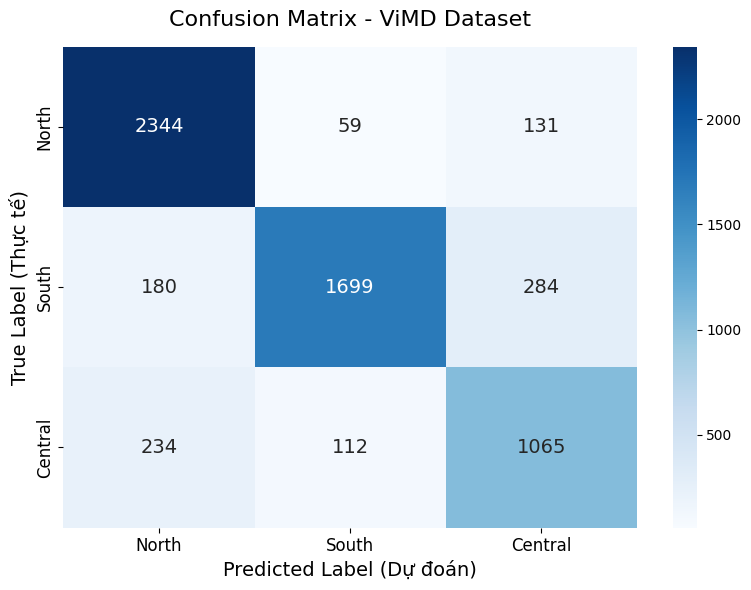


PER-CLASS ACCURACY (Tỉ lệ nhận diện đúng từng miền)
- Giọng North: 92.50%
- Giọng South: 78.55%
- Giọng Central: 75.48%


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Chạy dự đoán trên tập Test
print("Đang chạy dự đoán trên tập Test...")
# Sử dụng trainer từ Cell 8 để chạy dự đoán[cite: 2]
predictions_output = trainer.predict(test_dataset)

# 2. Lấy nhãn thực tế và nhãn dự đoán
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=1)

# Danh sách tên các nhãn (phải khớp thứ tự với label2id)
# Biến 'num_labels' và 'id2label' đã được định nghĩa ở Cell 3[cite: 2]
target_names = [id2label[i] for i in range(num_labels)]

# ==========================================
# 3. CLASSIFICATION REPORT (Báo cáo chi tiết)
# ==========================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Dữ liệu cho Paper)")
print("="*50)

# Phân tích: Recall của từng class chính là "Per-class Accuracy"
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# Lưu report ra file text để copy vào paper cho tiện
with open("/kaggle/working/classification_report_ViMD.txt", "w") as f:
    f.write(report)

# ==========================================
# 4. CONFUSION MATRIX (Ma trận nhầm lẫn)
# ==========================================
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ Heatmap cho Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14}) # Tăng kích cỡ chữ

plt.title('Confusion Matrix - ViMD Dataset', fontsize=16, pad=15)
plt.ylabel('True Label (Thực tế)', fontsize=14)
plt.xlabel('Predicted Label (Dự đoán)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Lưu hình ảnh chất lượng cao (300 dpi) để chèn vào paper
plt.savefig('/kaggle/working/confusion_matrix_ViMD.png', dpi=300)
plt.show()

# ==========================================
# 5. TÍNH ACCURACY TRÊN TỪNG CLASS RÕ RÀNG
# ==========================================
print("\n" + "="*50)
print("PER-CLASS ACCURACY (Tỉ lệ nhận diện đúng từng miền)")
print("="*50)

# Tránh lỗi chia cho 0 nếu có class không có dữ liệu
with np.errstate(divide='ignore', invalid='ignore'):
    class_accuracies = np.nan_to_num(cm.diagonal() / cm.sum(axis=1))

for i, acc in enumerate(class_accuracies):
    print(f"- Giọng {target_names[i]}: {acc*100:.2f}%")

# Checkpoint-2190 - On ViMD test set

Số lượng file ViMD Test: 2026

Đang tiến hành evaluate trên tập ViMD Dataset...
{'eval_loss': '0.8125', 'eval_accuracy': '0.8519', 'eval_f1': '0.8519', 'eval_runtime': '136.9', 'eval_samples_per_second': '14.8', 'eval_steps_per_second': '3.704'}

--- KẾT QUẢ ĐÁNH GIÁ TRÊN VIMD ---
eval_loss: 0.8125
eval_accuracy: 0.8519
eval_f1: 0.8519
eval_runtime: 136.8767
eval_samples_per_second: 14.8020
eval_steps_per_second: 3.7040

Đang chạy dự đoán chi tiết trên tập ViMD...

CLASSIFICATION REPORT VIMD (Dữ liệu cho Paper)
              precision    recall  f1-score   support

       North     0.8958    0.9221    0.9087       783
       South     0.8824    0.7984    0.8383       620
     Central     0.7724    0.8170    0.7941       623

    accuracy                         0.8519      2026
   macro avg     0.8502    0.8458    0.8470      2026
weighted avg     0.8537    0.8519    0.8519      2026



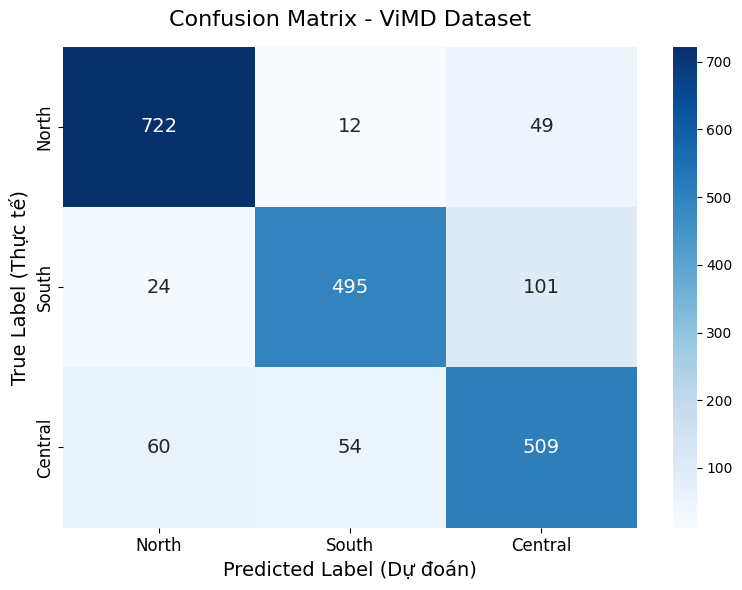


PER-CLASS ACCURACY VIMD (Tỉ lệ nhận diện đúng từng miền)
- Giọng North: 92.21%
- Giọng South: 79.84%
- Giọng Central: 81.70%


In [14]:
import os
import torch
import torchaudio
import librosa
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định cấu hình đường dẫn cho tập ViMD
VIMD_AUDIO_DIR = "/kaggle/input/datasets/phancongminh/vimd-dataset/vimd_dataset/test/audio_vimd"
VIMD_METADATA_PATH = "/kaggle/input/datasets/phancongminh/vimd-dataset/vimd_dataset/test/vimd_metadata.csv"

# 2. Định nghĩa Class Dataset riêng cho ViMD
class ViMDDataset(Dataset):
    def __init__(self, metadata_path, audio_dir, feature_extractor, label2id, max_duration=5.0):
        self.df = pd.read_csv(metadata_path)
        
        # Ép kiểu cột 'id' về chuỗi và đệm số 0 ở đầu cho đủ 6 ký tự
        self.df['id'] = self.df['id'].astype(str).apply(lambda x: x.zfill(6))
        
        self.audio_dir = audio_dir
        self.feature_extractor = feature_extractor
        self.max_duration = max_duration
        self.target_sr = feature_extractor.sampling_rate
        self.label2id = label2id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Lúc này row['id'] đã là chuỗi chuẩn xác (VD: '000000')
        file_path = os.path.join(self.audio_dir, f"{row['id']}.wav")
        region = row['region']
        label = self.label2id[region]

        # Load và xử lý âm thanh
        speech_array, sampling_rate = torchaudio.load(file_path)
        
        # Chuyển về mono nếu là stereo
        if speech_array.shape[0] > 1:
            speech_array = torch.mean(speech_array, dim=0, keepdim=True)
            
        speech_array = speech_array.squeeze(0).numpy()
        
        # Resample nếu không đúng sampling rate của model
        if sampling_rate != self.target_sr:
            speech_array = librosa.resample(np.asarray(speech_array), orig_sr=sampling_rate, target_sr=self.target_sr)
            
        # Trích xuất feature
        inputs = self.feature_extractor(
            speech_array, 
            sampling_rate=self.target_sr, 
            max_length=int(self.target_sr * self.max_duration), 
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in inputs.items()}
        item["labels"] = torch.tensor(label)
        return item

# 3. Khởi tạo dataset ViMD
# Lưu ý: label2id và num_labels đã được định nghĩa ở Cell 3 trong notebook của bạn
vimd_test_dataset = ViMDDataset(
    metadata_path=VIMD_METADATA_PATH,
    audio_dir=VIMD_AUDIO_DIR,
    feature_extractor=feature_extractor,
    label2id=label2id
)

print(f"Số lượng file ViMD Test: {len(vimd_test_dataset)}")

# 4. Tiến hành Evaluate cơ bản
print("\nĐang tiến hành evaluate trên tập ViMD Dataset...")
vimd_results = trainer.evaluate(vimd_test_dataset)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN VIMD ---")
for key, value in vimd_results.items():
    print(f"{key}: {value:.4f}")

# 5. Chạy dự đoán để lấy Classification Report & Confusion Matrix
print("\nĐang chạy dự đoán chi tiết trên tập ViMD...")
predictions_output = trainer.predict(vimd_test_dataset)

# Lấy nhãn thực tế và nhãn dự đoán
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=1)

target_names = [id2label[i] for i in range(num_labels)]

# ==========================================
# 6. CLASSIFICATION REPORT (Báo cáo chi tiết)
# ==========================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT VIMD (Dữ liệu cho Paper)")
print("="*50)

report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# Lưu report ra file text
with open("/kaggle/working/classification_report_ViMD.txt", "w") as f:
    f.write(report)

# ==========================================
# 7. CONFUSION MATRIX (Ma trận nhầm lẫn)
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14}) 

plt.title('Confusion Matrix - ViMD Dataset', fontsize=16, pad=15)
plt.ylabel('True Label (Thực tế)', fontsize=14)
plt.xlabel('Predicted Label (Dự đoán)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Lưu hình ảnh 
plt.savefig('/kaggle/working/confusion_matrix_ViMD.png', dpi=300)
plt.show()

# ==========================================
# 8. TÍNH ACCURACY TRÊN TỪNG CLASS RÕ RÀNG
# ==========================================
print("\n" + "="*50)
print("PER-CLASS ACCURACY VIMD (Tỉ lệ nhận diện đúng từng miền)")
print("="*50)

with np.errstate(divide='ignore', invalid='ignore'):
    class_accuracies = np.nan_to_num(cm.diagonal() / cm.sum(axis=1))

for i, acc in enumerate(class_accuracies):
    print(f"- Giọng {target_names[i]}: {acc*100:.2f}%")